# Loading pdf files and Vectorize the Conent

In [1]:
from unsloth import FastVisionModel
from pypdf import PdfReader
import os
from tqdm.notebook import tqdm
from pymed import PubMed
import json
import pytesseract
from pdf2image import convert_from_path

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
class PMCDocLoader:
    def __init__(self, data_dir, save_to):
        self.doc_content=[]
        self.data_dir = data_dir
        self.pubmed = PubMed(tool="MyTool", email="qzhao9@lakeheadu.ca")
        self.save_to = save_to
        self.min_words_per_line = 10
        self.pbar = None

    def get_pmc_metadata(self, pmc_ids):
        """
        Query document meta data
        """
        ids = ','.join([id.lstrip('PMC') for id in pmc_ids])
        try:
            results = self.pubmed._get("/entrez/eutils/esummary.fcgi",parameters={'db':'pmc','id':ids,'retmode':'json'})
            meta_result = results['result']
            uuids = meta_result['uids']
            metadata = {}
            for uuid in uuids:
                result = meta_result[uuid]
                authors = ', '.join([d['name'] for d in result['authors']])
                dois = [id['value'] for id in result['articleids'] if id['idtype']=='doi']
                if any(dois):
                    doi = dois[0]
                dois = '; '.join([f"{id['idtype'].upper()}:{id['value']}" for id in result['articleids']])
                cite_nlm = f"{authors}. {result['title']}. {result['source']}. {result['printpubdate']}; {result['volume']}({result['issue']}):{result['pages']}. Epub {result['epubdate']}. {dois}."
                # print(cite_nlm)
                metadata[f'PMC{uuid}'] = {
                                'id':f'PMC{uuid}',
                                'authors':authors,
                                'title': result['title'],
                                'doi':doi,
                                'cite':cite_nlm}
        except Exception as e:
            print('Failed to get meta data, error: ', e)
            return None

        return metadata


    def load(self, load_meta=True, save_output=True, limited_count=None, load_mode='pdf'):
        file_folders = os.listdir(self.data_dir)
        self.doc_content = []
        steps = 200
        file_folders = [folder for folder in file_folders if os.path.isdir(os.path.join(self.data_dir,folder))]
        
        if limited_count:
            file_folders = file_folders[:limited_count]

        self.pbar = tqdm(range(len(file_folders)))    
        if load_mode == 'pdf':
            load_fun = self.load_pdf_content
        elif load_mode == 'ocr':
            load_fun = self.load_pdf_content_ocr
        else:
            load_fun = None

        for i in range(0, len(file_folders), steps):
            batch = file_folders[i:i+steps]
            if load_meta:
                metadata = self.get_pmc_metadata(batch)
            for folder in tqdm(batch):
                try:
                    self.pbar.set_postfix({'Doc':folder})
                    full_path = os.path.join(self.data_dir,folder)
                    files = os.listdir(full_path)
                    num_of_pdf = len([f for f in files if f.endswith('.pdf') ])
                    if num_of_pdf == 0:
                        # print(folder,'No pdf file.')
                        continue

                    nxml_file = [f for f in files if f.endswith('.nxml')]
                    if not any(nxml_file):
                        continue
                    pdf_file = nxml_file[0].replace('.nxml','.pdf')
                    ful_pdf = os.path.join(full_path,pdf_file)
                    if load_fun is None:
                        if load_meta:
                            meta = metadata[folder]
                        else:
                            meta = {'id':folder}
                        self.doc_content.append(meta)
                    elif os.path.isfile(ful_pdf):
                        # Load Text Content
                        page_content = load_fun(ful_pdf)

                        # Load Images
                        reader = PdfReader(ful_pdf)
                        pypdf_pages = reader.pages
                        page_imgs = {}
                        for i, page in enumerate(pypdf_pages):
                            if not page.images:
                                continue
                            for img in page.images:
                                # img = img.convert("RGB")
                                img.image.save(os.path.join(full_path,img.name))
                            pil_images = [os.path.join(full_path,img.name) for img in page.images]
                            page_imgs[i] = pil_images

                        if not page_content:
                            continue
                        if load_meta:
                            meta = metadata[folder]
                        else:
                            meta = {'id':folder}
                        meta['content'] = page_content
                        meta['images'] = page_imgs
                        self.doc_content.append(meta)
                except Exception as e:
                    print('Failed to load pdf ', folder)
                    print(e)
                finally:
                    self.pbar.update(1)

        # Save extracted data
        if save_output:
            with open(self.save_to,'w+') as file:
                json.dump(self.doc_content,file)
        self.pbar.close()
        return True

    def load_fulltext(self, save_output=True, limited_count=None):
        file_folders = os.listdir(self.data_dir)
        self.doc_content = []
        steps = 200
        file_folders = [folder for folder in file_folders if os.path.isdir(os.path.join(self.data_dir,folder))]
        
        if limited_count:
            file_folders = file_folders[:limited_count]

        self.pbar = tqdm(range(len(file_folders)))    
        for i in range(0, len(file_folders), steps):
            batch = file_folders[i:i+steps]
           
            for folder in tqdm(batch):
                try:
                    self.pbar.set_postfix({'Doc':folder})
                    full_path = os.path.join(self.data_dir,folder)
                    files = os.listdir(full_path)
                    num_of_pdf = len([f for f in files if f.endswith('.pdf') ])
                    if num_of_pdf == 0:
                        # print(folder,'No pdf file.')
                        continue

                    nxml_file = [f for f in files if f.endswith('.nxml')]
                    if not any(nxml_file):
                        continue
                    pdf_file = nxml_file[0].replace('.nxml','.pdf')
                    ful_pdf = os.path.join(full_path,pdf_file)
                    if os.path.isfile(ful_pdf):
                        # Load Text Content
                        page_content = self.load_pdf_content_ocr(ful_pdf)                     

                        if not page_content:
                            continue
  
                        full_text = {'id':folder}
                        ft = ''
                        for pc in page_content:
                            ft = ' '.join([ft, ' '.join(pc)])
                        full_text['content'] = ft
                        self.doc_content.append(full_text)
                except Exception as e:
                    print('Failed to load pdf ', folder)
                    print(e)
                finally:
                    self.pbar.update(1)

            # Save extracted data
            if save_output:
                with open(self.save_to,'w+') as file:
                    json.dump(self.doc_content,file)
        self.pbar.close()
        return True
    
    def load_pdf_content(self, pdf_file):
        try:
            reader = PdfReader(pdf_file)

            total_pages = len(reader.pages)
            # print('Total Pages:',total_pages)

            # print('Page 1:',page_1.extract_text())
            pages = []
            for p in range(total_pages):
                page = reader.get_page(p)
                page_content = page.extract_text(space_width=250)
                page_content, is_reference = self.post_extract_processing(page_content)
                pages.append(page_content)
                if is_reference:
                    break
        except:
            print('Failed to load ', pdf_file)
            return None

        return pages
    
    def load_pdf_content_ocr(self, pdf_file):
        """
        Read pdf text using OCR.
        """
        try:
            ocr_pages = convert_from_path(pdf_file, 600)

            # print('Pages: ', len(pages))
            # extract text
            pages_text = []
            parent_dir_name = os.path.basename(os.path.dirname(pdf_file))
            for i, p in enumerate(ocr_pages):
                self.pbar.set_postfix({'Doc':parent_dir_name,'Page':f'{i+1}/{len(ocr_pages)}'})
                page_content = pytesseract.image_to_string(p)
                page_content, is_reference = self.post_extract_process_ocr(i, page_content)
                if page_content:
                    pages_text.append(page_content)
                if is_reference:
                    break
        except Exception as e:
            print('Failed to load ', pdf_file, e)
            # raise e
            return None
        return pages_text

    def post_extract_processing(self,page_number, page_content):
        """
        Clean up extracted text
        """
        lines = page_content.split('\n')
        # print(len(lines))
        new_lines = []
        is_reference = False
        start_of_content = False
        for i in range(len(lines)):
            # print(len(lines[i]))
            if new_lines:
                line_1 = new_lines[-1]
            else:
                line_1 = ''
            line_2 = lines[i]
            if page_number == 0 and not start_of_content:
                if not self.is_start_of_text(line_2):
                    continue
                else:
                    start_of_content = True

            if self.is_reference(line_2):
                # print('is_reference: True')
                is_reference = True
                break
            last_of_line_1 = line_1[-1] if line_1 else ''
            if last_of_line_1 in ['-',',',' ',';','"'] or last_of_line_1.isalpha():
                line_1 = line_1[:-1] if line_1[-1] == '-' else line_1
                new_lines[-1] = line_1 +(' ' if last_of_line_1.isalpha else '') +  line_2
            else:
                if not self.is_ignore(line_2):
                    new_lines.append(line_2)
                else:
                    pass
        return new_lines , is_reference #Paragraph
    
    def post_extract_process_ocr(self,page_number, page_content):
        lines = page_content.split('\n')

        if page_number == 0:
            # print(page_content)
            while lines and not self.is_start_of_text(lines[0]):
                lines.pop(0)
            if not lines: # Did not match 'Abstract', then load all.
                lines = page_content.split('\n')
        paragraphs = []
        p = ''
        is_reference = False
        for line in lines:
            if self.is_reference(line):
                is_reference = True
                break
            if line:
                p = p + (' ' if p and p[-1].isalpha() else '') + line
            elif len(p.split()) < self.min_words_per_line:
                p += ' '
            else:# a empty line is the paragraph break
                if not self.is_ignore(p):
                    paragraphs.append(p)
                p = ''
        if p:
            paragraphs.append(p)
        return paragraphs, is_reference

    def is_start_of_text(self,line):
        if line.startswith('Abstract'):
            return True
        
        return False
    
    def is_reference(self, line):
        if line.strip() == 'References':
            return True
        return False
    
    def is_ignore(self,line):
        if not line.strip():
            return True 
        if line.startswith('Acknowledgments') or\
              line.startswith('Conflicts of Interest') or\
              line.startswith('Author Contributions') or\
              line.startswith('Informed Consent Statement') or\
              line.startswith('Data Availability Statement'):
            return True
        # if len(line.strip().split()) < self.min_words_per_line:
        #     return True
        digits=[c for c in line if c.isdigit()]
        if len(digits) / len(line) >= 0.4:
            return True # Most of the charactors are numbers
        
        return False

In [78]:
# data_dir = r'/home/qzhao9/datasets/PMC-Papers/files'
data_dir = r'/home/qzhao9/datasets/PMC-Papers/manual_downloaded/files'
metadata_file = '/home/qzhao9/datasets/PMC-Papers/manual_downloaded/metadata.jsonl'

doc_loader = PMCDocLoader(data_dir,metadata_file)

doc_loader.load(load_meta=True, save_output=True, load_mode='ocr', limited_count=0)

print(len(doc_loader.doc_content))















100%|██████████| 12/12 [11:46<00:00, 58.84s/it, Doc=PMC5340806, Page=12/12] 

12


In [79]:
# data_dir = r'/home/qzhao9/datasets/PMC-Papers/files'
# fulltext_file = '/home/qzhao9/datasets/metadata_fulltext.jsonl'

data_dir = r'/home/qzhao9/datasets/PMC-Papers/manual_downloaded/files'
fulltext_file = '/home/qzhao9/datasets/PMC-Papers/manual_downloaded/metadata_fulltext.jsonl'

doc_loader = PMCDocLoader(data_dir,fulltext_file)

doc_loader.load_fulltext(save_output=True, limited_count=0)

print(len(doc_loader.doc_content))













100%|██████████| 12/12 [08:02<00:00, 40.23s/it, Doc=PMC5340806, Page=12/12]

12


In [35]:
!pip install pubmed-parser

  Using cached lxml-6.0.2-cp311-cp311-manylinux_2_26_x86_64.manylinux_2_28_x86_64.whl.metadata (3.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 MB 10.1 MB/s  0:00:05m0:00:0100:01
Using cached lxml-6.0.2-cp311-cp311-manylinux_2_26_x86_64.manylinux_2_28_x86_64.whl (5.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pubmed-parser]0m [pubmed-parser]


In [6]:
doc_loader.doc_content[0]
# page = doc_loader.load_pdf_content_ocr('/home/qzhao9/datasets/PMC-Papers/files/PMC10122388/12893_2023_Article_1984.pdf')
# print(page)

{'id': 'PMC9474497',
 'content': " Gut and Liver https://doi.org/10.5009/gnl210271pDISSN 1976-2283 elSSN 2005-1212 Check for updates Original Article Colonic Chicken Skin Mucosa Surrounding Colon Polyps Is an Endoscopic Predictive Marker for Colonic Neoplastic Polyps Yu Mi Lee'?, Kyung Ho Song’, Hoon Sup Koo’, Choong-Sik Lee*, Inseok Ko®, Sang Hyuk Lee’, and Kyu Chan Huh? ‘Health Screening and Promotion Center, Konyang University Hospital, 7Department of Gastroenterology, College of Medicine,Konyang University, Daejeon,7Department of Gastroenterology, CHA University llsan Medical Center, Ilsan, Departments of *Pathology and °Biomedical Informatics, College of Medicine, Konyang University, Daejeon, Korea Article Info Received June 24, 2021 Revised September 13, 2021Accepted October 21, 2021Published online January 7, 2022 Corresponding Author Kyu Chan Huh ORCID https://orcid.org/0000-0003-3746-8419E-mail kchuh2020@daum.net Yu Mi Lee and Kyung Ho Song contributed equally to this work as 

In [34]:
id = -1
ocr_pages = doc_loader.doc_content[id]['content']
lines_p1 = ocr_pages[2]
lines_p_end = ocr_pages[-4]
print(doc_loader.doc_content[id]['id'])
for l in lines_p1:
    print(l)

print('=='*30)
if not lines_p_end:
    print('empty page')
for l in lines_p_end:
    print(l)




PMC9170180
 
5


In [ ]:
import tiktoken
tokenizer = tiktoken.get_encoding("o200k_base")
print('tokenizer loaded.')

tokenizer loaded.


In [12]:
text = fulltext_of_docs[0]['content']
text = text.strip()
text = text.replace('  ',' ')
len(tokenizer.encode(text)), len(text.split())

(9657, 5646)

In [ ]:
import math

def fixed_length_chunking(text, length=512,overlap_rate=0.2):
    tokens = tokenizer.encode(text)
    chunks = []
    start = 0
    total_tokens = len(tokens)
    overlap = math.floor(length * overlap_rate)
    while start < total_tokens:
        chunk = tokens[start:start+length]
        text = tokenizer.decode(chunk)
        chunks.append(text)
        start = start + length - overlap
    return chunks

chunks = fixed_length_chunking(text,1024,0.2)
print(len(chunks),chunks)
print(chunks[0])
print(chunks[1])


12 ["Abstract Inflammatory diseases of the human gastrointestinal tract are affected by the microbes that reside in the mucosal surfaces. Pa-tients with inflammatory bowel diseases (IBD) have altered bacterial and fungal intestinal compositions, including higher levels of fecal Candida yeasts. Ongoing research indicates that genetic and phenotypic diversity of Candida albicans may be linked with disease severity. Here, we set out to investigate feces-derived C. albicans strains from individuals with IBD and healthy volunteers through microsatellite-based genotyping and phenotypic assays. A seven-locus microsatellite panel was applied, of which six loci were newly developed. It appears that there is no specific lineage of C. albicans that is associated with IBD, but rather that the three study popula-tions (Crohn’s disease, ulcerative colitis, healthy volunteers) do have distinguishable distributions of genotypes. In addition, pheno-typic characterization by means of enzyme release assa

## Create/Load ChromaDB Collection

In [1]:
import chromadb
from chromadb.utils.data_loaders import ImageLoader
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction

client = chromadb.PersistentClient('/home/qzhao9/datasets/chromadb')

data_loader = ImageLoader()
embedding_function = OpenCLIPEmbeddingFunction()

# coll_name='multimodal_collection'
coll_name='medical_tti'
# client.delete_collection(name=coll_name)
collection = client.get_or_create_collection(
    name=coll_name,
    embedding_function=embedding_function,
    data_loader=data_loader
)
print(f'ChromaDB collection {coll_name} loaded.')

ChromaDB collection medical_tti loaded.


In [ ]:
collection.get()

{'ids': [['PMC9813932_Fig_WJG-28-6632-g007', 'PMC11551702_Fig_97179-g001', 'PMC11765530_Fig_jcm-14-00333-g001']], 'embeddings': None, 'documents': None, 'uris': [['/home/qzhao9/datasets/PMC-Papers/manual_downloaded/files/PMC9813932/WJG-28-6632-g007.jpg', '/home/qzhao9/datasets/PMC-Papers/files/PMC11551702/97179-g001.jpg', '/home/qzhao9/datasets/PMC-Papers/manual_downloaded/files/PMC11765530/jcm-14-00333-g001.jpg']], 'included': ['metadatas', 'uris', 'distances'], 'data': None, 'metadatas': [[{'doc_type': 'image', 'caption': '\nNarrow-band Imaging International Colorectal Endoscopic classification. Citation: Puig I, Kaltenbach T. Optical Diagnosis for Colorectal Polyps: A Useful Technique Now or in the Future? Gut Liver 2018; 12: 385-392[150]. Copyright© The Author(s) 2018. Published by The Korean Society of Gastroenterology, the Korean Society of Gastrointestinal Endoscopy, the Korean Society of Neurogastroenterology and Motility, Korean College of Helicobacter and Upper Gastrointestin

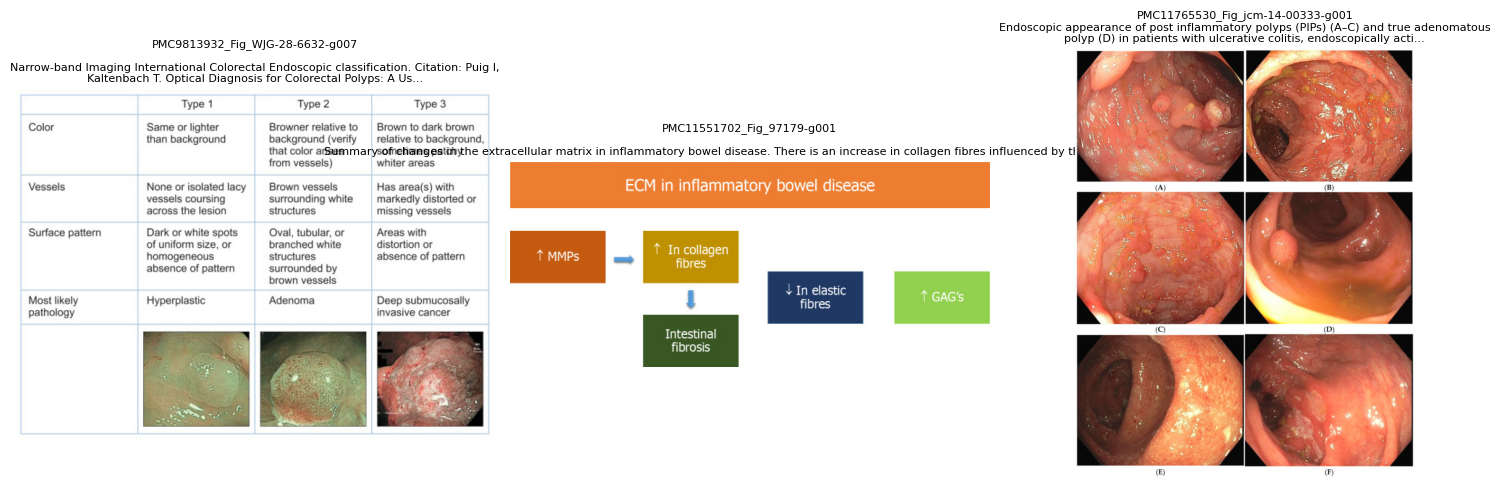

In [31]:
result = collection.query(query_texts=["Examples of various types of pseudopolyps in different patients with inflammatory bowel disease"], 
                 n_results=3, 
                 include=['metadatas','uris','distances'],
                 where={"doc_type":'image'})

print(result)
uris = result['uris']

# Show Images
from PIL import Image
import matplotlib.pyplot as plt
import os

if uris and uris[0]:
    num_images = len(uris[0])
    fig, axes = plt.subplots(1, num_images, figsize=(5*num_images, 5))
    
    if num_images == 1:
        axes = [axes]
    
    for i, uri in enumerate(uris[0]):
        if os.path.exists(uri):
            img = Image.open(uri)
            axes[i].imshow(img)
            caption = result['metadatas'][0][i].get('caption', 'No caption')
            axes[i].set_title(f"{result['ids'][0][i]}\n{caption[:150]}...", fontsize=8, wrap=True)
            axes[i].axis('off')
        else:
            axes[i].text(0.5, 0.5, f'Image not found:\n{uri}', ha='center', va='center')
            axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No images found in query results")


In [17]:
# Update metadata to add doc_type field for existing documents
from tqdm import tqdm

# Get all documents from the collection
all_docs = collection.get()
print(f"Total documents: {len(all_docs['ids'])}")

# Prepare updates
batch_size = 100
total_docs = len(all_docs['ids'])

for i in tqdm(range(0, total_docs, batch_size), desc='Updating metadata'):
    batch_end = min(i + batch_size, total_docs)
    batch_ids = all_docs['ids'][i:batch_end]
    batch_metadatas = all_docs['metadatas'][i:batch_end]
    
    # Update metadata with doc_type based on ID pattern
    updated_metadatas = []
    for doc_id, metadata in zip(batch_ids, batch_metadatas):
        if metadata is None:
            metadata = {}
        
        # Determine doc_type based on ID pattern
        if '_Fig_' in doc_id:
            metadata['doc_type'] = 'image'
        elif '_FigCaps_' in doc_id:
            metadata['doc_type'] = 'caption_text'
        else:
            metadata['doc_type'] = 'text'
        
        updated_metadatas.append(metadata)
    
    # Update the collection with new metadata
    collection.update(
        ids=batch_ids,
        metadatas=updated_metadatas
    )

print("Metadata update complete!")

Total documents: 35393


Updating metadata: 100%|██████████| 354/354 [14:05<00:00,  2.39s/it]

Metadata update complete!


In [ ]:
# Now query with the doc_type filter
collection.query(
    query_texts=["polyps in colonoscopy images"], 
    n_results=3,
    where={"doc_type": {"$in": ["image", "caption_text"]}}
)

## Load Data to ChromaDB V1  - Chunking by Page/Paragraph

In [19]:
import json


metadata_file = '/home/qzhao9/datasets/metadata.jsonl'
with open(metadata_file,'r+') as docfile:
    content_of_docs = json.load(docfile)

print('document loaded.')


document loaded.


In [9]:
from tqdm import tqdm

pbar = tqdm(content_of_docs[:], desc='Update collection')
for doc in pbar:
    doc_id = doc['id']
    ocr_pages = doc['content']
    images = doc['images']
    page_ids = [f'{doc_id}_P{i+1}' for i in range(len(ocr_pages))]
    pbar.set_postfix_str('Add Documents')
    for pid, paragraphs in enumerate(ocr_pages):
        ids = [f'{page_ids[pid]}_{i}' for i in range(len(paragraphs))]
        metadatas=[{'title':doc['title'],'page':pid,'cite':doc['cite']} for i in range(len(paragraphs))]
        collection.add(
            ids=ids,
            documents=paragraphs,
            metadatas=metadatas
        )
    pbar.set_postfix_str('Add Images')
    for key, vals in images.items():
       ids=[f'{doc_id}_IP{key}_{i}' for i in range(len(vals))]
       collection.add(
            ids=ids,
            uris=vals
        )


# def load_image(uri):
#     img = Image.open(uri)
#     img_np = np.array(img, dtype=np.uint8, copy=True)
#     return img_np

# collection.add(
#     ids=["id1", "id2"],
#     images=[load_image("/home/qzhao9/datasets/kvasir-dataset/polyps/0a874a44-90ea-42ea-a467-92a1d3a4a26c.jpg"), 
#           load_image("/home/qzhao9/datasets/kvasir-dataset/ulcerative-colitis/6acfb44a-2b22-4d49-a3bf-9ffc2461c3f9.jpg")]
# )
# # collection.add(
# #     ids=["id3", "id4"],
# #     documents=["This is a polyp image", "This is a UC image"]
# # )


Update collection: 100%|██████████| 1860/1860 [17:34:07<00:00, 34.00s/it, Add Images]       


## Load PMC Data to ChromaDB V2 - Chunking by langchain

In [32]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

lc_text_splitter = RecursiveCharacterTextSplitter(chunk_size=1024, chunk_overlap=20,separators=[
        "\n\n",
        "\n",
        " ",
        ".",
        # ",",
        "\uff0c",  # Fullwidth comma
        "\u3001",  # Ideographic comma
        "\uff0e",  # Fullwidth full stop
        "\u3002",  # Ideographic full stop
        # "",
    ],)

In [6]:
# Combine the previously saved metadata and newly created fulltext content
import json

metadata_file = '/home/qzhao9/datasets/PMC-Papers/manual_downloaded/metadata.jsonl'
with open(metadata_file,'r+') as docfile:
    meta_of_docs = json.load(docfile)

fulltext_file = '/home/qzhao9/datasets/PMC-Papers/manual_downloaded/metadata_fulltext.jsonl'
with open(fulltext_file,'r+') as docfile:
    fulltext_of_docs = json.load(docfile)

print('Documents Loaded.')

Documents Loaded.


### Use LLM to extract visual description from document

In [17]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

reprompt_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype="auto",
    device_map="auto"
)
reprompt_tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
prompt_template = """
You are a medical text excerptor.

Your task is to IDENTIFY and COPY excerpts from the provided text that contain
visual or image-observable descriptions related to:

1. Pseudopolyps (post-inflammatory polyps)
2. Colon polyps
3. Ulcerative colitis (endoscopic appearance only)

Rules:
- ONLY excerpt text that explicitly describes what can be seen on colonoscopy
  (shape, surface, size, number, distribution, mucosal appearance).
- COPY the original wording exactly as it appears in the text.
- DO NOT summarize, paraphrase, normalize, or rewrite.
- DO NOT include clinical interpretation, diagnosis, pathology, symptoms,
  treatment, risk, or outcomes.

- If no relevant visual excerpt exists for a category, return an empty list [].

Output format (STRICT JSON, no extra text):

{
  "pseudopolyps": [
    "verbatim excerpt 1",
    "verbatim excerpt 2"
  ],
  "colon_polyps": [
    "verbatim excerpt 1"
  ],
  "ulcerative_colitis": [
    "verbatim excerpt 1"
  ]
}


"""

In [34]:
fulltext_of_docs[0]['content']

" Gut and Liver https://doi.org/10.5009/gnl210271pDISSN 1976-2283 elSSN 2005-1212 Check for updates Original Article Colonic Chicken Skin Mucosa Surrounding Colon Polyps Is an Endoscopic Predictive Marker for Colonic Neoplastic Polyps Yu Mi Lee'?, Kyung Ho Song’, Hoon Sup Koo’, Choong-Sik Lee*, Inseok Ko®, Sang Hyuk Lee’, and Kyu Chan Huh? ‘Health Screening and Promotion Center, Konyang University Hospital, 7Department of Gastroenterology, College of Medicine,Konyang University, Daejeon,7Department of Gastroenterology, CHA University llsan Medical Center, Ilsan, Departments of *Pathology and °Biomedical Informatics, College of Medicine, Konyang University, Daejeon, Korea Article Info Received June 24, 2021 Revised September 13, 2021Accepted October 21, 2021Published online January 7, 2022 Corresponding Author Kyu Chan Huh ORCID https://orcid.org/0000-0003-3746-8419E-mail kchuh2020@daum.net Yu Mi Lee and Kyung Ho Song contributed equally to this work as first authors. Background/Aims: N

In [33]:
gen_kwargs = dict(
        max_new_tokens=65532,
        do_sample=False,
        temperature=0.0,
        top_p=1.0,
        top_k=0,
        num_beams=1,   # greedy
    )


# prompt = prompt_template.format(scenarios[i])
chunks = lc_text_splitter.split_text(fulltext_of_docs[0]['content'])
for c in chunks:
    print('Original Chunk:\n', c)
    messages = [
        # {"role": "system", "content": """You are a helpful clinic assistant and colonoscope image expert. You analyze the user-provided context carefully. 
        
        #  Find out the main anatomical conception mentioned,and use your knowledge provide visual details such as shape, texture, color, location, and size.
        #  You use them to build a anatomic focusing prompt for generating medical colonoscope images. 
        
        #  Limit the length to within 70 words."""},
        {"role":"system", "content": prompt_template},
        {"role": "user", "content": c}
    ]
    text = reprompt_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    model_inputs = reprompt_tokenizer([text], return_tensors="pt").to(reprompt_model.device)
    print('Model inputs prepared.')
    generated_ids = reprompt_model.generate(
        **model_inputs,
        **gen_kwargs,
    )
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    response = reprompt_tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    print("Excerpts", ":\n", response)


Original Chunk:
 Gut and Liver https://doi.org/10.5009/gnl210271pDISSN 1976-2283 elSSN 2005-1212 Check for updates Original Article Colonic Chicken Skin Mucosa Surrounding Colon Polyps Is an Endoscopic Predictive Marker for Colonic Neoplastic Polyps Yu Mi Lee'?, Kyung Ho Song’, Hoon Sup Koo’, Choong-Sik Lee*, Inseok Ko®, Sang Hyuk Lee’, and Kyu Chan Huh? ‘Health Screening and Promotion Center, Konyang University Hospital, 7Department of Gastroenterology, College of Medicine,Konyang University, Daejeon,7Department of Gastroenterology, CHA University llsan Medical Center, Ilsan, Departments of *Pathology and °Biomedical Informatics, College of Medicine, Konyang University, Daejeon, Korea Article Info Received June 24, 2021 Revised September 13, 2021Accepted October 21, 2021Published online January 7, 2022 Corresponding Author Kyu Chan Huh ORCID https://orcid.org/0000-0003-3746-8419E-mail kchuh2020@daum.net Yu Mi Lee and Kyung Ho Song contributed equally to this work as first authors. Bac

KeyboardInterrupt: 

### Other

In [10]:
print(meta_of_docs[0])
print(fulltext_of_docs[0])

{'id': 'PMC9474497', 'authors': 'Lee YM, Song KH, Koo HS, Lee CS, Ko I, Lee SH, Huh KC', 'title': 'Colonic Chicken Skin Mucosa Surrounding Colon Polyps Is an Endoscopic Predictive Marker for Colonic Neoplastic Polyps', 'doi': '10.5009/gnl210271', 'cite': 'Lee YM, Song KH, Koo HS, Lee CS, Ko I, Lee SH, Huh KC. Colonic Chicken Skin Mucosa Surrounding Colon Polyps Is an Endoscopic Predictive Marker for Colonic Neoplastic Polyps. Gut Liver. 2022 Sep 15; 16(5):754-763. Epub 2022 Jan 7. PMID:35000932; DOI:10.5009/gnl210271; PMCID:PMC9474497.', 'content': [['Gut and Liver https://doi.org/10.5009/gnl210271pDISSN 1976-2283 elSSN 2005-1212 Check for updates', 'Original Article Colonic Chicken Skin Mucosa Surrounding Colon Polyps Is an Endoscopic Predictive Marker for Colonic Neoplastic Polyps', "Yu Mi Lee'?, Kyung Ho Song’, Hoon Sup Koo’, Choong-Sik Lee*, Inseok Ko®, Sang Hyuk Lee’, and Kyu Chan Huh?", '‘Health Screening and Promotion Center, Konyang University Hospital, 7Department of Gastroent

In [15]:
import random

# Optional: set a seed for reproducibility
# random.seed(42)

k = min(30, len(fulltext_of_docs))
sampled_docs = random.sample(fulltext_of_docs, k=k)

# Quick sanity check
print(f"Sampled {len(sampled_docs)} records")
print([d.get('id') for d in sampled_docs[:]])

Sampled 30 records
['PMC10918762', 'PMC9582296', 'PMC8477705', 'PMC10816523', 'PMC8870533', 'PMC6020513', 'PMC10515252', 'PMC7040482', 'PMC3516479', 'PMC10434883', 'PMC8742196', 'PMC9324090', 'PMC7820867', 'PMC11834365', 'PMC11280167', 'PMC8028202', 'PMC11173774', 'PMC11201305', 'PMC7830946', 'PMC6570620', 'PMC4542423', 'PMC10836595', 'PMC6266508', 'PMC7760122', 'PMC7834247', 'PMC5752714', 'PMC10280014', 'PMC7136702', 'PMC10492092', 'PMC6529172']


In [31]:
excerpt = {'PMC10918762':'the effectiveness of VDZ therapy', 
 'PMC9582296':'association between socioeconomic status with clinical outcome with patients with ulcerative colitis',  
 'PMC8477705':'the relationship between frailty and IBD, the epidemiology of frailty in IBD, and ramifications of frailty in IBD',
'PMC10816523':'connection between SAA and higher disease activity in patients with IBD', 
'PMC8870533':'need of GI-related major ambulatory surgeries,a higher prevalence of IBD-related ambulatory surgeries', 
'PMC6020513':'economic evaluations performed in the context of IBD', 
'PMC10515252':'METTL3,formation of the inflammatory microenvironment', 
'PMC7040482':'CRC in selected Balkan countries', 
'PMC3516479':'genetic models, cause of CRC', 
'PMC10434883':'colonoscopy effects using CO2 insufflation in patients with ulcerative colitis', 
'PMC8742196':'mechanisms of Epac-­2 in Il-­10−/− mice', 
'PMC9324090':'an extracorporeal side-to-side (SS) or end-to-side (ES) stapled anastomosis impacts short-term and long-term outcomes after an oncological laparoscopic right hemicolectomy', 
'PMC7820867':'CRC and CRC-S molecular inﬂammatory response', 
'PMC11834365':'treatment algorithm for patients with moderate ulcerative colitis', 
'PMC11280167':'imbalanced dietary intake is also characteristic among individuals with IBD during clinical remission', 
'PMC8028202':'eating rate and eating until full may be independently inversely associated with MH', 
'PMC11173774':'IBD was associated with an overall low quality of diet independently of disease type and phenotype', 
'PMC11201305':'effect of sulfonylureas on the prevention of CD, GERD, chronic gastritis, and the development of gastric ulcers', 
'PMC7830946':'the main coumarin derivatives reported as intestinal anti-inflammatory products and its available pharmacodynamic data', 
'PMC6570620':'role of OAB preparation,either in combination with MBP or in the prevention of postoperative complications in elective colorectal surgery.', 
'PMC4542423':'the association of bactericidal permeability increasing protein gene polymorphism with steroid use and dependence in Crohn’s disease', 
'PMC10836595':'association between T2DM and CRC or IBD.', 
'PMC6266508':'effectiveness of oral adjuvant curcumin therapy to attaining remission, or ameliorating clinical response among patients with UC.', 
'PMC7760122':'essential role of HO-1 and its end-products for ensuring the gastrointestinal tract health and how its dysfunction lead to several disorders', 
'PMC7834247':'does treatment with biologic drug represent a risk factor for the SARS-CoV-2 infection?', 
'PMC5752714':'association between WASP with the pathogenesis of a subtype of IBD patients', 
'PMC10280014':'role of BAA2573 on the gut microbiota', 
'PMC7136702':'effectiveness of Endoscopic stricturotomy (ESt) for treatment of IBD-associated strictures', 
'PMC10492092':'IBD is causally associated with increased risk of pancreatic cancer.', 
'PMC6529172':'incidence and risk of HZ in Asian patients with IBD'
}

In [14]:
from tqdm import tqdm
docs_to_load = len(meta_of_docs)
pbar = tqdm(total=docs_to_load, desc='Add docs to collection')
docs = meta_of_docs[0:docs_to_load] #,fulltext_of_docs[:docs_to_load])
# pbar.update(431)
for metadata in docs:
    fulltext = [f for f in fulltext_of_docs if f['id']==metadata['id']]
    if fulltext:
        fulltext = fulltext[0]
    else:
        pbar.update(1)
        continue
    # assert metadata['id'] == fulltext['id']
    doc_id = metadata['id']
    content = fulltext['content']
    chunks = lc_text_splitter.split_text(content)
    images = metadata['images']
    chunk_ids = [f'{doc_id}_{i}' for i in range(len(chunks))]
    pbar.set_postfix_str(f'Add Documents of {doc_id}')
    metadatas=[{'title':metadata['title'],'cite':metadata['cite']} for i in range(len(chunks))]
    collection.add(
        ids=chunk_ids,
        documents=chunks,
        metadatas=metadatas
    )
    pbar.set_postfix_str(f'Add Images of {doc_id}')
    for key, vals in images.items():
       ids=[f'{doc_id}_P{key}_{i}' for i in range(len(vals))]
       collection.add(
            ids=ids,
            uris=vals
        )
    pbar.update(1)

pbar.clear()
pbar.close()

Add docs to collection: 100%|██████████| 5/5 [02:12<00:00, 26.41s/it, Add Images of PMC9813932]    


## Load PMC Data to ChromaDB V2 - Chunking by Section

In [ ]:
import pubmed_parser as pp
import os
import json

def load_content_to_chromadb(collection, pmc_files_root):
    """
    Load PMC documents and images to ChromaDB collection.
    @param collection: ChromaDB collection object
    @param pmc_files_root: Root directory of PMC files. There should be a 'files' sub-directory containing PMC document folders,
        and 'metadata.jsonl' and 'metadata_fulltext.jsonl' files containing metadata information.
    """
    metadata_file = os.path.join(pmc_files_root, 'metadata.jsonl')
    with open(metadata_file,'r+') as docfile:
        meta_of_docs = json.load(docfile)

    fulltext_file = os.path.join(pmc_files_root, 'metadata_fulltext.jsonl')
    with open(fulltext_file,'r+') as docfile:
        fulltext_of_docs = json.load(docfile)

    tqdm.write('Documents Loaded.')

    data_dir = os.path.join(pmc_files_root, 'files')
    docs = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir,d))]
    tqdm.write(f'Total docs: {len(docs)}')

    pbar = tqdm(range(len(docs)), desc='Add docs to collection', position=0, leave=True)
    # pbar.update(1855)
    for d in docs[:]:
        current_section = ''
        chunks = []
        metadatas = []
        path = os.path.join(data_dir,d)

        nxml_file = [f for f in os.listdir(path) if f.endswith('.nxml')]
        if not any(nxml_file):
            continue
        nxml_path = os.path.join(path,nxml_file[0])
        try:
            dicts_out = pp.parse_pubmed_paragraph(nxml_path, all_paragraph=True)
            tqdm.write(f'Doc: {d}, Paragraphs: {len(dicts_out)}',end='')
            doc_meta = [m for m in meta_of_docs if m['id']==d]
            if not doc_meta:
                doc_meta = {'title':'','cite':''}
            else:
                doc_meta = doc_meta[0]
            
            for p in dicts_out:
                section = p['section']
                if section and section != current_section:
                    current_section = section
                    # tqdm.write(f'== Section: {section}')
                    chunks.append(p['text'])
                    metadatas.append({'title':d,'section':current_section,'cite':doc_meta['cite']})
                else:
                    # print('== Section:', current_section)
                    if len(chunks) == 0:
                        chunks.append(p['text'])
                        metadatas.append({'title':d,'section':current_section,'cite':doc_meta['cite']})
                    else:
                        chunks[-1] = ' '.join([chunks[-1], p['text']])
            # tqdm.write(f'Total Chunks: {len(chunks)}')
            chunk_ids = [f'{d}_{i}' for i in range(len(chunks))]
            pbar.set_postfix_str(f'Add Documents of {d}')

            figs = pp.parse_pubmed_caption(nxml_path)
            ids = []
            ids_t = []
            uris = []
            meta_datas = []
            captions = ''
            if figs:
                for c in figs:
                    caption = c['fig_caption']
                    img_ref = c['graphic_ref']
                    img_name = f'{img_ref}.jpg'
                    img_path = os.path.join(path, img_name)
                    if os.path.isfile(img_path):
                        ids.append(f'{d}_Fig_{img_ref}')
                        uris.append(img_path)
                        meta_datas.append({'caption': caption})
                        captions += caption + ' '
                # tqdm.write(f'Doc: {d}, Images: {len(ids)}')


                pbar.set_postfix_str(f'Add Images of {d}')
                
                collection.add(
                    ids=ids,
                    uris=uris,
                    metadatas=meta_datas
                )
                
                chunk_ids.append(f'{d}_FigCaps_')
                chunks.append(captions)
                metadatas.append({'title':d,'section':'Figure Captions','cite':doc_meta['cite']})

            collection.add(
                ids=chunk_ids,
                documents=chunks,
                metadatas=metadatas
            )
        except Exception as e:
            tqdm.write(f'Failed to load images for {d}, error: {e}')
            
        finally:
            pbar.update(1)


# load_content_to_chromadb(collection, '/home/qzhao9/datasets/PMC-Papers/manual_downloaded')
load_content_to_chromadb(collection, '/home/qzhao9/datasets/PMC-Papers')

Documents Loaded.
Total docs: 1911


Add docs to collection:   0%|          | 0/1911 [00:00<?, ?it/s]

Error: it was not able to read a path, a file-like object, or a string as an XML
Failed to load images for PMC7312994, error: Start tag expected, '<' not found, line 1, column 1 (<string>, line 1)


Failed to load images for PMC11945304, error: cannot access local variable 'caption' where it is not associated with a value


Failed to load images for PMC9161899, error: cannot access local variable 'caption' where it is not associated with a value


### Classify visual/non-visual content

In [47]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

reprompt_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype="auto",
    device_map="auto"
)
reprompt_tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
prompt_template = """
You are a medical text excerptor.

Your task is to IDENTIFY and COPY excerpts from the provided text that contain
visual or image-observable descriptions related to:

1. Pseudopolyps (post-inflammatory polyps)
2. Colon polyps
3. Ulcerative colitis (endoscopic appearance only)

Rules:
- ONLY excerpt text that explicitly describes what can be seen on colonoscopy
  (shape, surface, size, number, distribution, mucosal appearance).
- COPY the original wording exactly as it appears in the text.
- DO NOT summarize, paraphrase, normalize, or rewrite.
- DO NOT include clinical interpretation, diagnosis, pathology, symptoms,
  treatment, risk, or outcomes.

- If no relevant visual excerpt exists for a category, return an empty list [].

Output format (STRICT JSON, no extra text):

{
  "pseudopolyps": [
    "verbatim excerpt 1",
    "verbatim excerpt 2"
  ],
  "colon_polyps": [
    "verbatim excerpt 1"
  ],
  "ulcerative_colitis": [
    "verbatim excerpt 1"
  ]
}


"""

In [89]:
gen_kwargs = dict(
        max_new_tokens=65532,
        do_sample=False,
        temperature=0.0,
        top_p=1.0,
        top_k=0,
        num_beams=1,   # greedy
    )

prompt_template = """
Task: Binary classification.

Definition:
VISUAL = the text contains ANY explicit mention of visible appearance
(e.g., shape, color, texture, surface, spatial form),
even if brief, definitional, or part of a larger clinical discussion.

Answer ONLY one token:
VISUAL or NON-VISUAL

Text:
{input}
"""


def classify_excerpts(text_chunks):
    messages = [
        # {"role":"system", "content": prompt_template},
        {"role": "user", "content": prompt_template.format(input=text_chunks)}
    ]
    text = reprompt_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    model_inputs = reprompt_tokenizer([text], return_tensors="pt").to(reprompt_model.device)
    # print('Model inputs prepared.')
    generated_ids = reprompt_model.generate(
        **model_inputs,
        **gen_kwargs,
    )
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    response = reprompt_tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    print("Excerpts", ":\n", response)
    return response


In [63]:
import numpy as np
import pandas as pd

pmc_files_root = '/home/qzhao9/datasets/PMC-Papers'
data_dir = os.path.join(pmc_files_root, 'files')
docs = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir,d))]

np.random.seed(42)
sampled_docs = np.random.choice(docs, size=20, replace=False)
print('Sampled Docs:', sampled_docs)

paras = []
for doc in sampled_docs:
    try:
        path = os.path.join(data_dir,doc)
        nxml_file = [f for f in os.listdir(path) if f.endswith('.nxml')]
        if not any(nxml_file):
            continue
        nxml_path = os.path.join(path,nxml_file[0])
        dicts_out = pp.parse_pubmed_paragraph(nxml_path, all_paragraph=True)
        for p in dicts_out:
            if not p['text'] or len(p['text'].strip().split()) < 20:
                continue
            result = classify_excerpts(p['text'])
            if 'NON-VISUAL' in result.upper():
                continue
            paras.append({
                # 'doc_id': doc,
                # 'section': p['section'],
                'text': p['text'],
                'is_visual': 0
            })
    except Exception as e:
        print(f'Failed to process doc {doc}, error: {e}')
        continue

# paras = np.random.choice(paras, size=500, replace=False)
df_paras = pd.DataFrame(list(paras))
df_paras.to_csv(f'{pmc_files_root}/sampled_pmc_paragraphs.csv', index=False)
    # print('Paragraphs:', len(dicts_out))
    # print(dicts_out[0])

    # captions = pp.parse_pubmed_caption(path)
    # print('Captions:', len(captions))
    # print(captions)
# for p in dicts_out:
#     print(p['text'])
# # print(dicts_out)


Sampled Docs: ['PMC11568146' 'PMC10798864' 'PMC9409909' 'PMC5956562' 'PMC11521495'
 'PMC5369074' 'PMC11696058' 'PMC12537108' 'PMC11324338' 'PMC11463058'
 'PMC12079478' 'PMC10163486' 'PMC10663299' 'PMC8088576' 'PMC10627604'
 'PMC10532020' 'PMC10333679' 'PMC3388477' 'PMC6131907' 'PMC6425155']
Excerpts :
 NON-VISUAL
Excerpts :
 VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL
Excerpts :
 NON-VISUAL

KeyboardInterrupt: 

## Visual Only Collection

In [ ]:
import chromadb
from chromadb.utils.data_loaders import ImageLoader
from chromadb.utils import embedding_functions
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction

client = chromadb.PersistentClient('/home/qzhao9/datasets/chromadb')

data_loader = ImageLoader()
embedding_function = OpenCLIPEmbeddingFunction()

medical_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="pritamdeka/S-PubMedBert-MS-MARCO",  # Medical domain
    device="cuda"
)

# coll_name='multimodal_collection'
coll_name='medical_tti_visualonly'
# client.delete_collection(name=coll_name)
collection = client.get_or_create_collection(
    name=coll_name,
    embedding_function=medical_ef,
    # data_loader=None
)
print(f'ChromaDB collection {coll_name} loaded.')

old_collection = client.get_collection(name='medical_tti')

ChromaDB collection medical_tti_visualonly loaded.


In [3]:
import re
from tqdm import tqdm

def extract_visual_descriptors(clinical_report):
    """Extract only visual/endoscopic descriptions"""
    
    # Visual keywords
    visual_keywords = [
        'surface', 'appearance', 'color', 'shape', 'texture',
        'nodular', 'smooth', 'lobulated', 'pedunculated', 'sessile',
        'pink', 'red', 'pale', 'erythematous', 'borders', 'margins',
        'elevated', 'flat', 'polypoid', 'round', 'oval'
    ]
    
    # Exclude pathology keywords
    pathology_keywords = [
        'adenocarcinoma', 'tumor', 'malignant', 'infiltrat',
        'metasta', 'signet ring', 'ki-67', 'pathological',
        'histology', 'biopsy', 'cytoplasm', 'nucleus'
    ]
    
    sentences = re.split(r'[.;]\s+', clinical_report)
    visual_sentences = []
    
    for sentence in sentences:
        sentence_lower = sentence.lower()
        
        # Skip if contains pathology terms
        if any(term in sentence_lower for term in pathology_keywords):
            continue
        
        # Include if contains visual terms
        if any(term in sentence_lower for term in visual_keywords):
            visual_sentences.append(sentence.strip())
    
    return visual_sentences

# Process your existing database
def clean_database():
    # Get all documents
    all_docs = old_collection.get()
    print(f'Total documents in old collection: {len(all_docs["documents"])}')
    visual_docs = []
    metas = []
    for i, doc in tqdm(enumerate(all_docs['documents']), total=len(all_docs['documents']), desc='Processing documents'):
        if not doc:
            continue
        visual_sents = extract_visual_descriptors(doc)
        if visual_sents:
            visual_docs.append(' '.join(visual_sents))
            metas.append(all_docs['metadatas'][i])
    print(f'Total visual documents extracted: {len(visual_docs)}')
    
    ids=[f"visual_{i}" for i in range(len(visual_docs))]
    batch_size = 100
    for i in tqdm(range(0, len(visual_docs), batch_size), desc='Adding visual documents to new collection'):
        batch_docs = visual_docs[i:i+batch_size]
        batch_ids = ids[i:i+batch_size]
        meta = metas[i:i+batch_size]
        collection.add(
            documents=batch_docs,
            ids=batch_ids,
            metadatas=meta
        )
    
    return collection

In [4]:
collection = clean_database()

Total documents in old collection: 35393


Processing documents: 100%|██████████| 35393/35393 [00:02<00:00, 17593.93it/s]


Total visual documents extracted: 19309


Adding visual documents to new collection: 100%|██████████| 194/194 [03:56<00:00,  1.22s/it]


In [5]:
collection.count()

19309

In [6]:
# Test queries
test_queries = [
    "smooth surface polyp",
    "pedunculated lesion appearance",
    "polyp color characteristics"
]

for query in test_queries:
    results = collection.query(query_texts=[query], n_results=3)
    print(f"\nQuery: {query}")
    print(f"Results: {results['documents'][0]}")


Query: smooth surface polyp
Results: ['The first type is composed only from mucosa, which can be relatively intact or edematous, representing mucosal remnants between zones of ulceration and which, for most authors, are considered the "true\'\' PPs[10] (Figure 1A) B: Localized pseudopolyps of varying size up to 1.6 cm with discrete borders, pale surface, exudates on surface and varying forms H: Pseudopolyp or adenoma-like mass? Solitary polyp with 1.5 cm size and broad-based with discrete borders but without exudates, amenable to endoscopic removal and having a pale surface J: Localized pseudopolyps of 0.3 cm maximum size, located in sigmoid colon with discrete borders and pale, glistering surface Kelly et al[6] divided PP types into polypoid mucosal tags and mature inflammatory polyps, encompassing essentially all the previous forms, and proposed the term inflammatory polyp as the most appropriate for general use', 'B: Localized pseudopolyps of varying size up to 1.6 cm with discrete

## Validate collection

In [2]:
print(client.heartbeat())
print(collection.count())

1770077463808413734
35393


In [82]:
results = collection.query( query_texts="""post-inflammatory polyps pseudopolyps finger-like""", 
                            n_results=5)
(results['documents'][0])

['The development of post-inflammatory polyps, usually termed “pseudopolyps”, is relatively common feature in inflammatory bowel diseases [1]. In rare cases, these polyps form large agglomerations of filiform projections; if they measure >15 mm in any direction, they are defined as giant inflammatory polyps [2,3]. The probable pathogenetic basis of such an entity is repeated episodes of inflammation and healing within the colonic surface, with the formation of polypoid projections of residual mucosa amidst surrounding ulcerated areas. Giant inflammatory polyps occur in both ulcerative colitis and Crohn’s disease patients [2]. Given their clinical, endoscopic and radiologic appearance, giant inflammatory polyps can easily be mistaken for colorectal carcinoma [4]. Here we present a case of a giant inflammatory polyp as the first manifestation of inflammatory bowel disease. It was initially mistaken for colonic cancer, and its histopathologic features regarding inflammatory bowel disease 

In [96]:
classify_excerpts('Data on the treatment of giant inflammatory polyps are generally scarce. Conservative (medical), endoscopic or surgical methods can be used.')

Excerpts :
 VISUAL


'VISUAL'

In [32]:
match_results = []
for key, value in excerpt.items():
    res = collection.query( query_texts=value, n_results=5)
    print(f'Query for {key} - {value}')
    m = 0
    for doc_id, doc, meta in zip( res['ids'][0], res['documents'][0], res['metadatas'][0]):
        print(f'ID: {doc_id}\nDoc: {doc}\n---')
        if key in doc_id:
            m = 1
    print('=='*40)
    match_results.append(m)

print(f'Matched {sum(match_results)}/{len(excerpt)} queries.')
    

Query for PMC10918762 - the effectiveness of VDZ therapy
ID: PMC10918762_43
Doc: 12 months of VDZ therapy, but VDZ therapy had to be discontinued because of the reim-bursement policy. Therefore, the patients in our study expe-rienced a shorter time to relapse, which implies that it is less appropriate to discontinue VDZ before achieving adequate disease control in these patients. Our study had several limitations. We collected data from different centers, and although we expected the patient populations to be similar given the similarities in geograph-ical regions and the types of medical centers, heteroge-neity remained in the data collected and potentially in the populations of these centers. Furthermore, the registry still actively registers patients; only patients with 6 months or 12months of follow-up were used in our analysis. However, this study also has several strengths. First, this was the first na-tionwide registry study reporting the long-term effectiveness of VDZ therapy f

# QA with RAG

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM, set_seed
import torch, json
from peft import PeftModel,PeftModelForQuestionAnswering

IS_VL = False
if IS_VL:
    # model_name='Qwen/Qwen2.5-1.5B-Instruct'
    model_name = "Qwen/Qwen2.5-VL-3B-Instruct" #"Qwen/Qwen3-0.6B"
    # tokenizer = AutoTokenizer.from_pretrained(model_name)
    # model = AutoModelForCausalLM.from_pretrained(model_name, device_map="cuda")

    qa_model, tokenizer = FastVisionModel.from_pretrained(model_name,
                                                    load_in_4bit=True,
                                                    use_gradient_checkpointing='unsloth')
    adapter_path = '/mnt/disk2/ft_model_output/qwen2.5-3b-instruct-trl-sft-ChartQA/checkpoint-100'
    qa_model = PeftModelForQuestionAnswering.from_pretrained(qa_model, adapter_path)
else:
    model_name='Qwen/Qwen2.5-1.5B-Instruct'
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    qa_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")    
print('Qwen model is loaded to ', qa_model.device)
qa_model.eval()



Qwen model is loaded to  cuda:0


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((1536,), eps=1e-06)
    (rotar

In [5]:
from qwen_vl_utils import process_vision_info

def pico_prompt(question):
    template = f"""
You are a clinical evidence extraction assistant.
Rewrite the following medical question into structured PICO format:

P: Patient / Population  
I: Intervention  
C: Comparison  
O: Outcome  

Question: {question}

Return only structured PICO elements.
            """
    return template


def pico_query(img, user_query):
    prompt = pico_prompt(user_query)
    # print(prompt)
    # print('=='*50)
    pico = query(img,prompt)
    return pico

def query(img, prompt):
    if IS_VL:
        messages ={
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "image": img,
                    },
                    {
                        "type": "text",
                        "text": prompt,
                    }
                ],
            }
            
        ]
        }
    else:
        messages ={
        "messages": [
            {
                "role": "user",
                "content": prompt,
            }
            
        ]
        }
    # print(messages)
    text = tokenizer.apply_chat_template(
    messages['messages'],
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=True
     )
    print('Generated Prompt: ', text)
    image_inputs, _ = process_vision_info(messages['messages'])
    if IS_VL:
        inputs = tokenizer(text=[text],
                        images=[img.resize([512,512]) for img in image_inputs],
                        return_tensors="pt").to('cuda')
    else:
        inputs = tokenizer([text], return_tensors="pt").to(qa_model.device)
        
    tokens = qa_model.generate(**inputs, 
                            max_new_tokens=32768,
                            do_sample=False,  # Enable sampling
                            temperature=0.1, # Control randomness (optional)
                            top_k=20,        # Control sampling pool (optional)
                            top_p=0.9,      # Control sampling pool (optional)
                            num_return_sequences=1,)
    output = tokenizer.decode(tokens[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return output 

def retrieve_top_k(pico_query, k=3):
    # q_emb = embedder.encode([pico_query], convert_to_numpy=True)
    # distances, indices = index.search(q_emb, k)
    
    # retrieved = [corpus[i] for i in indices[0]]
    results = collection.query( query_texts=[pico_query], 
                        #    query_uris=['/home/qzhao9/datasets/PMC-Papers/files/PMC11781193/Im1.jpg'],
                            n_results=k)
    # print(results['documents'])
    retrieved = results['documents']
    return retrieved

In [6]:
scenario_1 = """A 45-year-old man undergoing surveillance colonoscopy for long-standing ulcerative colitis was found to have a solitary, 
            well-demarcated sessile polyp measuring approximately 12 mm in the sigmoid colon. The surrounding mucosa showed chronic inflammatory changes with mild erythema but no active ulceration. 
            Narrow-band imaging demonstrated an irregular surface pattern and altered vascular architecture within the lesion, raising concern for dysplasia-associated lesion or mass (DALM). 
            Targeted biopsies were obtained to distinguish inflammatory pseudopolyp from neoplastic colonic polyp."""
q_pico = pico_prompt(scenario_1)
result = pico_query(None, scenario_1)
print(result)

Generated Prompt:  <|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user

You are a clinical evidence extraction assistant.
Rewrite the following medical question into structured PICO format:

P: Patient / Population  
I: Intervention  
C: Comparison  
O: Outcome  

Question: A 45-year-old man undergoing surveillance colonoscopy for long-standing ulcerative colitis was found to have a solitary, 
            well-demarcated sessile polyp measuring approximately 12 mm in the sigmoid colon. The surrounding mucosa showed chronic inflammatory changes with mild erythema but no active ulceration. 
            Narrow-band imaging demonstrated an irregular surface pattern and altered vascular architecture within the lesion, raising concern for dysplasia-associated lesion or mass (DALM). 
            Targeted biopsies were obtained to distinguish inflammatory pseudopolyp from neoplastic colonic polyp.

Return only structured PICO eleme

In [9]:
retrieve_top_k(result)

[['We included patients who received a colonoscopy between 2001 and 2010. The indications for colonoscopy were as follows: i) asymptomatic screening, ii) post-polypectomy surveillance, and iii) a positive FIT. We systematically excluded patients aged < 20 years, those with a previous diagnosis of colorectal cancer or inflammatory bowel disease. We also excluded patients who received colonoscopy with a colorectal cancer diagnosis within 6 month as to exclude procedures intended to diagnose colorectal cancer in S1 Fig (because these could have potentially biased the association between colonoscopy and cancer death and incidence). These eligible criteria were similar to previous studies.[16, 20–24] This study was approved by the Institutional Review Board of The University of Tokyo (No. 2058).',
  "Colonoscopy is routinely performed for colorectal cancer (CRC) screening, fecal immunochemical test (FIT)‐positive follow‐up, diagnosis of symptoms, surveillance, and polypectomy.\n, \n Its suc

In [10]:
retrieve_top_k(scenario_1)

[['\nPreoperative colonoscopy. The surface showed nodular or cauliflower-like changes; the rectal mucosa was congested and showed edema; the surface showed longitudinal changes, with many scattered small ulcers and a little mucus-like white coating on the surface or a small amount of bleeding. The intestinal cavity was so narrow that the endoscope was unable to pass. \nPreoperative computed tomography examination. A: The rectal wall thickened uniformly in stages, and the intestinal cavity was obviously narrowed; B: The rectal mucosal layer was obviously strengthened (the area indicated by the white arrow, 2019/11/28). \nGross specimen after surgery. The excised intestine had a length of 67 cm and a diameter of 3.5-7.5 cm. The intestine was cut along the opposite side of the mesentery. There were multiple congestions with superficial ulcers on the mucosal surface of the intestinal canal, with a segmental distribution. The wall of the tube 1-16 cm from the rectal stump was diffusely thic

In [14]:
retrieve_top_k('finger-like structures arising after repeated inflammation')

[['\nIncreased inflammatory response can lead to barrier disruption, allowing bacterial translocation into the intestinal lumen. These pathogens trigger an immune and inflammatory response, perpetuating the inflammatory process. Inflammatory cells can also cause dysplasia, leading to the development of colorectal cancer (CRC). Under normal conditions, epithelial cells, during β-oxidation, decrease oxygen availability, thus creating an anaerobic environment. During chronic inflammation, β-oxidation decreases, enhancing oxygen availability. This also leads to an increase in nitrate (NO3-) formation, leading to dysbiosis and growth of proteobacteria such as Escherichia coli (E. coli). E. coli produces colibactin, which could damage DNA and stimulate tumor growth. The growth of Bacteroidetes fragilis may also occur, which produces Bacteroides fragilis toxin (BFT). This toxin cleaves E-cadherin, a major constituent of the zonula adherens, which is responsible for cell adhesion, leading to f

In [13]:
retrieve_top_k('chronic colonic inflammation producing elongated mucosal structures')

[['Colonic drug delivery has been an area of high interest over the past decades, with research being driven by improved therapeutic outcomes of local disorders such as inflammatory bowel disease (IBD), colorectal cancer and Clostridioides difficile infection (CDI), alongside systemic delivery of macromolecules such as protein and peptide drugs via oral routes [1,2,3]. A successful system requires a stable payload, which transverses the stomach and small intestine without premature release and degradation. There are physiological distinctions of the colon in comparison to the proximal gastrointestinal tract that can be leveraged, with key differences including pH and microbiota [3–6].\xa0 no caption available However, these characteristics are subject to great intra and interindividual variability, and gastrointestinal disorders can further alter colonic physiology [3,7]. It has been reported that colonic pH is reduced in patients with ulcerative colitis [8], IBD patients tend to have 

In [6]:
from transformers import pipeline, AutoTokenizer

# tokenizer = AutoTokenizer.from_pretrained(
#     "distilbert-base-cased-distilled-squad",
#     use_fast=True
# )

generator = pipeline("question-answering", 
                        model=qa_model,  #'distilbert-base-cased-distilled-squad', 
                        tokenizer=tokenizer,
                        # use_fast=True
                        )

Device set to use cuda:0
The model 'PeftModelForCausalLM' is not supported for question-answering. Supported models are ['PeftModelForQuestionAnswering', 'AlbertForQuestionAnswering', 'ArceeForQuestionAnswering', 'BartForQuestionAnswering', 'BertForQuestionAnswering', 'BigBirdForQuestionAnswering', 'BigBirdPegasusForQuestionAnswering', 'BloomForQuestionAnswering', 'CamembertForQuestionAnswering', 'CanineForQuestionAnswering', 'ConvBertForQuestionAnswering', 'Data2VecTextForQuestionAnswering', 'DebertaForQuestionAnswering', 'DebertaV2ForQuestionAnswering', 'DiffLlamaForQuestionAnswering', 'DistilBertForQuestionAnswering', 'ElectraForQuestionAnswering', 'ErnieForQuestionAnswering', 'ErnieMForQuestionAnswering', 'Exaone4ForQuestionAnswering', 'FalconForQuestionAnswering', 'FlaubertForQuestionAnsweringSimple', 'FNetForQuestionAnswering', 'FunnelForQuestionAnswering', 'GPT2ForQuestionAnswering', 'GPTNeoForQuestionAnswering', 'GPTNeoXForQuestionAnswering', 'GPTJForQuestionAnswering', 'IBertF

In [5]:
qa_prompt = {
'v0':"""
You are a medical expert. 

=== Question ===
{question}

Provide a detailed medical answer with a rationale referencing the evidence.
""",

'v1':"""
You are a medical expert. Use ONLY the evidence provided.

=== Evidence ===
{context}

=== Question ===
{question}

Provide:
1. A concise medical answer.
2. A rationale referencing the evidence
3. Confidence level (low / medium / high)
""",

'v2':"""
You are a medical expert. Use ONLY the evidence provided.

=== Evidence ===
{context}

Answer the following question.
=== Question ===
{question}

Provide a detailed medical answer with a rationale referencing the evidence.
""",

'v3':"""
You are a medical expert. You are given the following evidence from medical literature:
=== Evidence ===
{context}

A polyp and UC detection system has returned the following results for the image: UC severity level is {uc_severity}; {num_polyps}. Include those details in your answer.

Answer the following question.
=== Question ===
{question}

Provide a detailed medical answer (for example, number of polyps found, the severity of UC), and clarify the answer with a rationale referencing the evidence. 
"""
}

def medical_rag_qa(img,question, prompt_version='v2',uc_severity=None, num_of_polyps=None):
    # Step 1 — Convert to PICO
    pico_question = pico_query(img,question)
    # print('=========== Generated PICO Format Question =====================================')
    # print(pico_question)
    # Step 2 — Retrieve evidence
    retrieved = retrieve_top_k(pico_question, k=5)
    # context = "\n".join(retrieved[0])
    context = ""
    # Step 3 — Construct final answer prompt
    # if uc_severity:
    #     # question = f'From the given image, the patient has ulcerative colitis with severity level: {uc_severity}. {question}'
    #     context = f'The patient has ulcerative colitis with severity level: {uc_severity}.\n' + context
        
    final_prompt = qa_prompt[prompt_version].format(context=context, 
                                                    question=question, 
                                                    uc_severity=uc_severity if uc_severity else 'N/A', 
                                                    num_polyps=f'{num_of_polyps} polyps were detected' if num_of_polyps else 'No polyp was detected')
    # print('=========== QA Prompt =====================================')
    # print(final_prompt)
    # Step 4 — Generate final answer
    result = query(img,final_prompt)
    answer = result 
    return answer,context


In [8]:
# display image from array
# Convert PIL image to displayable format
import numpy as np
import matplotlib.pyplot as plt
import  PIL.Image as PImage

def display_seg_image(pred_result, orig_img, cam_img,uc_severity):
    img_to_display = PImage.open(orig_img)
    w,h = img_to_display.size
    max_box_area = 0.6*w*h # max area threshold

    boxes = pred_result.boxes.xyxy.cpu().numpy()
    # Filter boxes that are too large
    box_ids = [i for i, box in enumerate(boxes) if (box[2]-box[0])*(box[3]-box[1]) <= max_box_area]
    boxes = boxes[box_ids]
    labels = [pred_result.names[int(cls)] for cls in pred_result.boxes.cls.cpu().numpy()[box_ids]]
    scores = pred_result.boxes.conf.cpu().numpy()[box_ids]
    # number_of_plts = 3
    # if not boxes.any():
    #     number_of_plts = 2
    # if not cam_img.any():
    #     number_of_plts = 1
    f, ax = plt.subplots(1, 2, figsize=(18, 8))

    ax[0].imshow(img_to_display)
    ax[0].set_title('Original Image')
    ax[0].axis('off')
    # next_ax = 1
    ax[1].imshow(cam_img)
    if boxes.any():
        title = 'Detected Polyps and/or UC (Severity Level: ' + uc_severity + ')'
    else:
        title = f'UC Severity Detection ({uc_severity})'
    ax[1].set_title(title)
    if boxes.any():
        # ax[1].imshow(img_to_display)
        # ax[1].set_title('Detected Polyps')

        for box, label, score in zip(boxes, labels, scores):
            x1, y1, x2, y2 = box
            width, height = x2 - x1, y2 - y1
            rect = plt.Rectangle((x1, y1), width, height, fill=False, color='red', linewidth=2)
            ax[1].add_patch(rect)
            if label == 'OTHER':
                ax[1].text(x1, y1, f'Polyp, Score: {score:.2f}', bbox=dict(facecolor='yellow', alpha=0.5))
            else:
                ax[1].text(x1, y1, f'Polyp ({label}), Score: {score:.2f}', bbox=dict(facecolor='yellow', alpha=0.5))
        # next_ax +=1
    plt.axis('off')
    plt.show()
    return len(box_ids) # number of detected polyps

In [9]:
from ultralytics import YOLO
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import torchvision.transforms as T
# import PIL.Image as Image

# Load a COCO-pretrained YOLO11n model
pre_trained_model = '/home/qzhao9/code/9800/gradproj/experiments/runs/detect/train_without_augmentation8/weights/best.pt'
seg_model = YOLO(pre_trained_model)

size ='x_non_normalized'
model_path = f'/home/qzhao9/code/9800/gradproj/experiments/runs/classify/uc-clf_26{size}/weights/best.pt'
clf_model = YOLO(model_path) 


def classify_uc_severity(model, img_path):
    yolo_seq_model = model.model.model
    yolo_seq_model[10].conv.conv.weight.requires_grad = True
    print(yolo_seq_model[10].conv.conv.weight.requires_grad)

    results = model(img_path, imgsz=288,save=False)
    top1_pred = results[0].probs.top1
    predited_class = results[0].names[top1_pred]
    lbl = results[0].probs.top1
    target_layer = yolo_seq_model[10].conv
    target_layers = [target_layer]
    targets = [ClassifierOutputTarget(lbl)]

    orig_img = PImage.open(img_path).convert('RGB')
    img = np.array(orig_img)
    img = np.float32(img) / 255
    transform = T.Compose(
                [
                    T.ToTensor(),
                ])
    input_tensor = transform(orig_img).unsqueeze(0)
    model.eval()
    if not target_layer.conv.weight.requires_grad:
        target_layer.conv.weight.requires_grad = True

    with GradCAM(model=model.model, target_layers=target_layers) as cam:
        # You can also pass aug_smooth=True and eigen_smooth=True, to apply smoothing.
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets, aug_smooth=True, eigen_smooth=True)
        # In this example grayscale_cam has only one image in the batch:
        grayscale_cam = grayscale_cam[0, :]
        visualization = show_cam_on_image(img, grayscale_cam, use_rgb=False, image_weight=0.7)
    
    return predited_class, visualization
        

## Question:

Are there any abnormalities in the image? Check all that are present.

## Analyzing Image:

True

image 1/1 /home/qzhao9/datasets/Kvasir-VQA-x1/images/cl8k2u1pu1e37083257oa5xt6.jpg: 546x626 Mayo 2 0.43, Mayo 1 0.34, Mayo 3 0.18, Mayo 0 0.04, 16.3ms
Speed: 18.3ms preprocess, 16.3ms inference, 0.1ms postprocess per image at shape (1, 3, 546, 626)

image 1/1 /home/qzhao9/datasets/Kvasir-VQA-x1/images/cl8k2u1pu1e37083257oa5xt6.jpg: 672x768 2 OTHERs, 5.7ms
Speed: 2.4ms preprocess, 5.7ms inference, 1.1ms postprocess per image at shape (1, 3, 672, 768)


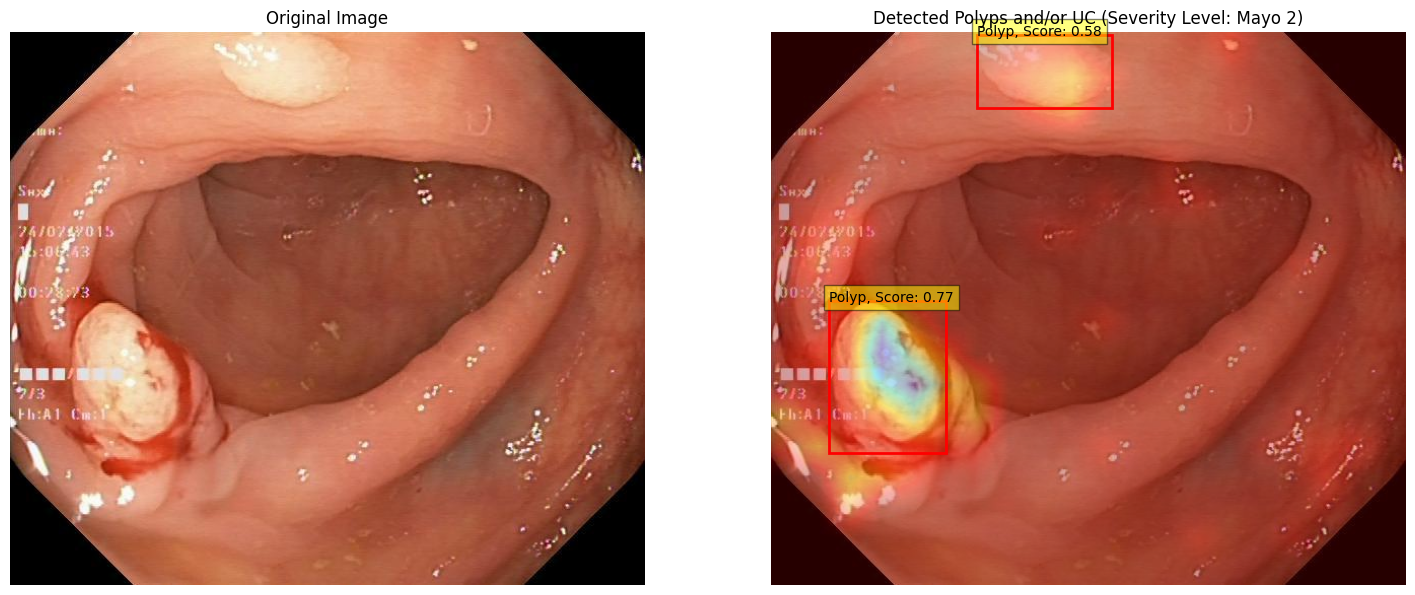

Detected UC severity: Mayo 2, Number of polyps detected: 2
Generated Prompt:  <|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>
You are a clinical evidence extraction assistant.
Rewrite the following medical question into structured PICO format:

P: Patient / Population  
I: Intervention  
C: Comparison  
O: Outcome  

Question: Are there any abnormalities in the image? Check all that are present.

Return only structured PICO elements.
            <|im_end|>
<|im_start|>assistant

Generated Prompt:  <|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>
You are a medical expert. You are given the following evidence from medical literature:
=== Evidence ===


A polyp and UC detection system has returned the following results for the image: UC severity level is Mayo 2; 2 polyps were detected. Include those details in your answer.

Answer the following quest

## Answer:

Evidence of two polyps and moderate ulcerative colitis is present.

In [12]:
import traceback
from IPython.display import display, Markdown, Image
import os
import gc

torch.manual_seed(27603)
#Are there any abnormalities in the image? Check all that are present.
question="""
Are there any abnormalities, e.g polyps and UC  in the image, and how would you grade its severity? Describe the characteristics of the abnormalities and provide relevant clinical recommendations based on established medical guidelines.

"""
question = "Are there any abnormalities in the image? Check all that are present."
img = "/home/qzhao9/datasets/Kvasir-VQA-x1/images/cl8k2u1pu1e37083257oa5xt6.jpg"
# img = '/home/qzhao9/datasets/kvasir-dataset/normal-cecum/0ab26ff5-3161-4a17-bcf4-95663033af0a.jpg'
# img ='/home/qzhao9/datasets/kvasir-dataset/ulcerative-colitis/1fd0b100-f61b-421a-aadc-30a5e05662bb.jpg'
# img = "/home/qzhao9/datasets/kvasir-dataset/ulcerative-colitis/023c18dc-b0fb-47d2-8f80-1eef4dec876e.jpg"
# img = '/home/qzhao9/datasets/kvasir_vqa/images/cla820gl0s3nz071uch6e0sas.jpg' #ulcerative colitis
# img = '/home/qzhao9/datasets/kvasir_vqa/images/cla820gl1s3oz071u2ixjf7yk.jpg' # 1 finding, Ulcerative Colitis
# img = '/home/qzhao9/datasets/kvasir_vqa/images/clb0kvxwj929c074yhbmvg5fy.jpg' # Barrett's esophagus
# img = '/home/qzhao9/datasets/kvasir_vqa/images/clbnxtoxh6vsi079o6ignhh7q.jpg' # Normal  
# # Display the image using IPython.display
# if os.path.exists(img):
#     display(Image(filename=img,width=400, height=400))
# else:
#     display(Markdown(f"Image not found: {img}"))
# print(os.path.exists(img))
# print(pico_query(img, question))
try:
    display(Markdown("## Question:"))
    display(Markdown(question))
    display(Markdown("## Analyzing Image:"))
    uc_severity, cam_image = classify_uc_severity(clf_model, img)
    pred_results = seg_model(img, conf=0.5)
    num_polyps = display_seg_image(pred_results[0], img, cam_image,uc_severity)
    print(f'Detected UC severity: {uc_severity}, Number of polyps detected: {num_polyps}')
    answer,evidence = medical_rag_qa(img,question,'v3',uc_severity,num_polyps)
    display(Markdown("## Answer:"))
    display(Markdown(answer))
    # display(Markdown("### Retrieved Evidence:"))
    display(Markdown(evidence))
    # pred_results[0].show()
except Exception as e:
    print('Error during medical_rag_qa: ', e)
    traceback.print_exc()
finally:
    # clear GPU cache
    torch.cuda.empty_cache()
    gc.collect()

In [43]:
# v0: vidence of a Paris IIa polyp is present, consistent with a Paris classification system.

# v1: Evidence of a small polyp noted in the colon, consistent with Paris IIa classification, and no other significant findings observed.

# v2: Evidence of multiple polyps observed, with Paris IIa morphology noted, consistent with a low-grade lesion.

In [115]:
pred_results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([], device='cuda:0')
conf: tensor([], device='cuda:0')
data: tensor([], device='cuda:0', size=(0, 6))
id: None
is_track: False
orig_shape: (532, 633)
shape: torch.Size([0, 6])
xywh: tensor([], device='cuda:0', size=(0, 4))
xywhn: tensor([], device='cuda:0', size=(0, 4))
xyxy: tensor([], device='cuda:0', size=(0, 4))
xyxyn: tensor([], device='cuda:0', size=(0, 4))